In [1]:
import torch
from torch import nn
from torch.nn import functional as f
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split

from torchmetrics.classification import Accuracy, Recall, BinaryF1Score


In [2]:
import random
import os
import numpy as np
import torch

def set_seed(seed=42):
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    
    np.random.seed(seed)        

set_seed(616) 

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"目前使用的裝置: {device}")

目前使用的裝置: cpu


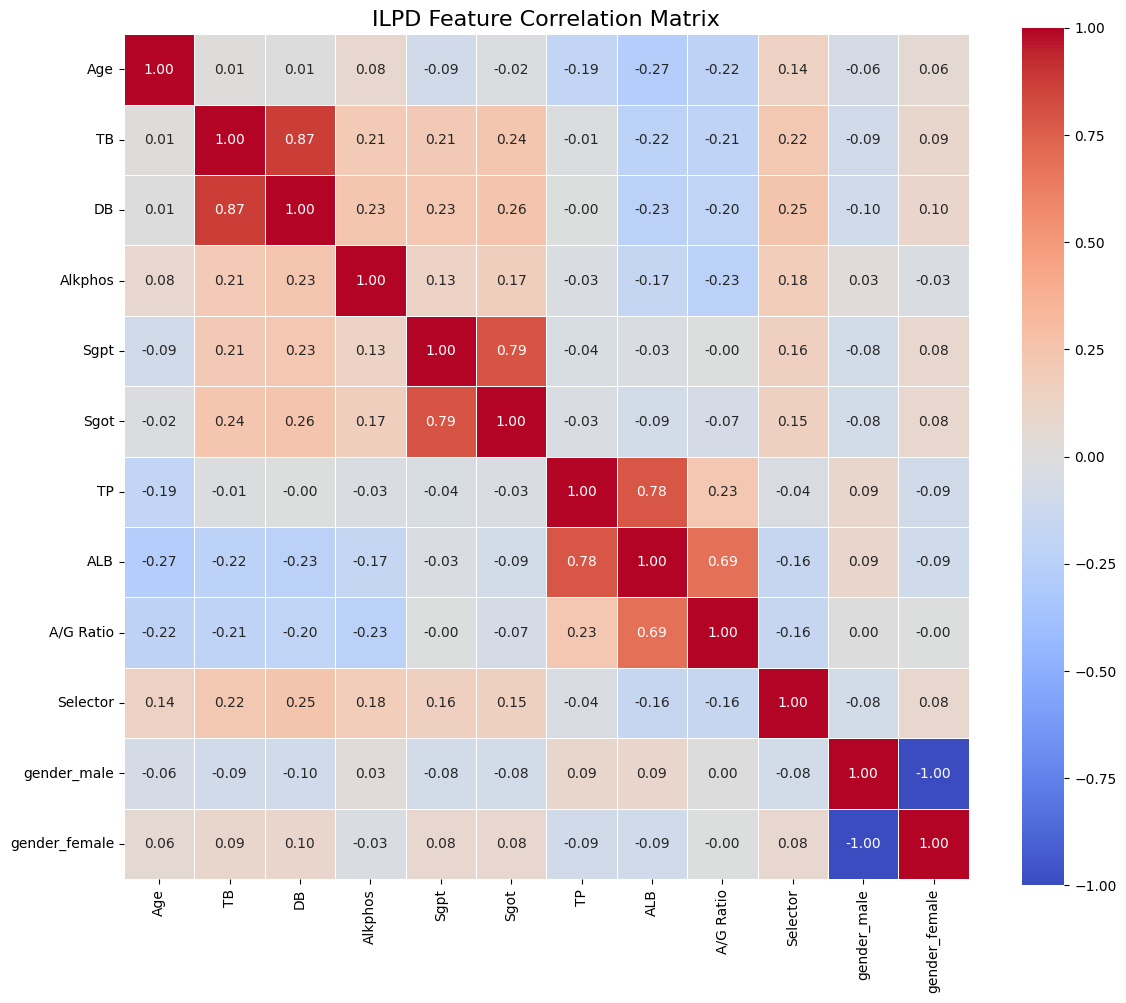

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 計算相關係數矩陣 (假設 df 是您包含 11 維特徵與 Selector 的 DataFrame)
corr_matrix = df.corr()

# 2. 設定畫布大小
plt.figure(figsize=(12, 10))

# 3. 繪製熱圖 (Heatmap)
# vmin/vmax 設定範圍在 -1 到 1，cmap 使用藍紅對比色調
sns.heatmap(
    corr_matrix, 
    annot=True,          # 在格子內顯示數字
    fmt=".2f",          # 小數點後兩位
    cmap="coolwarm",     # 藍色代表負相關，紅色代表正相關
    linewidths=0.5,      # 格子間的線寬
    square=True          # 讓格子保持正方形
)

plt.title("ILPD Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/input/datasets/fatemehmehrparvar/liver-disorders/Indian Liver Patient Dataset (ILPD).csv")
df['A/G Ratio'] = df['A/G Ratio'].fillna(df['A/G Ratio'].mean())

labelencoder = LabelEncoder()
onehotencoder = OneHotEncoder()
df["Gender"] = labelencoder.fit_transform(df["Gender"])
onehot_df = onehotencoder.fit_transform(df[["Gender"]])
onehot_df = pd.DataFrame(onehot_df.toarray(), columns=["gender_male", "gender_female"])
df = pd.concat([df, onehot_df], axis=1)
df = df.drop(columns='Gender')

df['AST_ALT_Ratio'] = df['Sgot'] / (df['Sgpt'] + 1e-5)

features_to_drop = ['DB', 'TP', 'Sgot', 'Sgpt', 'gender_male', 'gender_female']
df_cleaned = df.drop(columns=features_to_drop)

# 3. 提取 6 維特徵與標籤
x = df_cleaned.drop(columns = "Selector").values
y = df["Selector"].values
y[y == 2] = 0 

x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(x, y, test_size=0.2, random_state=621)

m_scaler = MinMaxScaler()
x_train_scaled = m_scaler.fit_transform(x_train_raw)
x_test_scaled = m_scaler.transform(x_test_raw)


x_train = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test = torch.tensor(x_test_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_raw, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test_raw, dtype=torch.float32).view(-1, 1)

x_1 = x_train[(y_train == 1).view(-1)]
x_0 = x_train[(y_train == 0).view(-1)]

# 7. 驗證最終維度
print(f"訓練集特徵形狀: {x_train.shape}") # 預期: [N, 6]
print(f"測試集特徵形狀: {x_test.shape}")  # 預期: [M, 6]
print(f"純訓練集健康樣本 (x_0) shape: {x_0.shape}")
print(f"純訓練集患病樣本 (x_1) shape: {x_1.shape}")

訓練集特徵形狀: torch.Size([466, 6])
測試集特徵形狀: torch.Size([117, 6])
純訓練集健康樣本 (x_0) shape: torch.Size([138, 6])
純訓練集患病樣本 (x_1) shape: torch.Size([328, 6])


In [56]:
class VAE(nn.Module):

    def __init__(self, input_dim=6, hidden_dim=32, latent_dim=4, scale_factor = 1.0):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = f.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-20.0, max=20.0)
        return mu, logvar

    def reparameterize(self, mu, logvar, alpha=1.0):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + alpha * (eps * std)

    def decode(self, z):
        h = f.relu(self.fc2(z))
        return f.sigmoid(self.fc3(h)) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar, alpha=1.5)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

def vae_loss(recon_x, x, mu, logvar, kl_weight=0.01):
    recon_loss = f.binary_cross_entropy(recon_x, x, reduction="mean")
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + (kl_weight * kl_loss)
    return total_loss, recon_loss, kl_loss

vae_dataset = TensorDataset(x_0)
vae_loader = DataLoader(vae_dataset, batch_size=64, shuffle=True)

VAE_model = VAE()
optimizer = Adam(VAE_model.parameters(), lr=0.001)

epochs = 400

for epoch in range(epochs):
    VAE_model.train()
    total_VAEloss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    kl_weight = min(1.0, epoch / 50.0) * 0.1 

    for batch in vae_loader:
        batch_data = batch[0]
        
        optimizer.zero_grad()
        recon, mu, logvar = VAE_model(batch_data)
        VAEloss, recon_loss, kl_loss = vae_loss(recon, batch_data, mu, logvar, kl_weight)

        VAEloss.backward()
        optimizer.step()
        
        total_VAEloss += VAEloss.item() * len(batch_data)
        total_recon_loss += recon_loss.item() * len(batch_data)
        total_kl_loss += kl_loss.item() * len(batch_data)

    total_samples = len(x_0)
    avg_loss = total_VAEloss / total_samples
    avg_recon_loss = total_recon_loss / total_samples
    avg_kl_loss = total_kl_loss / total_samples

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Recon: {avg_recon_loss:.4f} | "
            f"KL: {avg_kl_loss:.4f} (wt: {kl_weight:.3f})"
        )


Epoch [1/400] Loss: 0.6575 | Recon: 0.6575 | KL: 0.0242 (wt: 0.000)
Epoch [10/400] Loss: 0.5766 | Recon: 0.5765 | KL: 0.0065 (wt: 0.018)
Epoch [20/400] Loss: 0.5259 | Recon: 0.5244 | KL: 0.0400 (wt: 0.038)
Epoch [30/400] Loss: 0.4974 | Recon: 0.4924 | KL: 0.0864 (wt: 0.058)
Epoch [40/400] Loss: 0.4890 | Recon: 0.4839 | KL: 0.0663 (wt: 0.078)
Epoch [50/400] Loss: 0.4764 | Recon: 0.4723 | KL: 0.0417 (wt: 0.098)
Epoch [60/400] Loss: 0.4748 | Recon: 0.4727 | KL: 0.0216 (wt: 0.100)
Epoch [70/400] Loss: 0.4699 | Recon: 0.4686 | KL: 0.0129 (wt: 0.100)
Epoch [80/400] Loss: 0.4672 | Recon: 0.4665 | KL: 0.0076 (wt: 0.100)
Epoch [90/400] Loss: 0.4659 | Recon: 0.4654 | KL: 0.0052 (wt: 0.100)
Epoch [100/400] Loss: 0.4612 | Recon: 0.4608 | KL: 0.0030 (wt: 0.100)
Epoch [110/400] Loss: 0.4621 | Recon: 0.4619 | KL: 0.0024 (wt: 0.100)
Epoch [120/400] Loss: 0.4608 | Recon: 0.4607 | KL: 0.0016 (wt: 0.100)
Epoch [130/400] Loss: 0.4592 | Recon: 0.4590 | KL: 0.0014 (wt: 0.100)
Epoch [140/400] Loss: 0.4582 | 

In [39]:
def sampling_fn(num_samples=80, device=device):
    """
    從真實健康樣本 (x_0) 的隱空間後驗分佈中進行重抽樣，生成高品質健康樣本。
    """
    VAE_model.eval()

    x_0_dev = x_0.to(device) 
    
    with torch.no_grad():
        mu_0, logvar_0 = VAE_model.encode(x_0_dev)
        std_0 = torch.exp(0.5 * logvar_0)
        

        center_mu = mu_0.mean(dim=0, keepdim=True)
        center_std = std_0.mean(dim=0, keepdim=True)
        
        epsilon = torch.randn(num_samples, center_mu.size(1), device=device)
        z = center_mu + epsilon * center_std

        generated_data = VAE_model.decode(z).detach()


    y_generated = torch.zeros(num_samples, 1, device=device)


    x_train_dev = x_train.to(device)
    y_train_dev = y_train.to(device)

    x_train_sampling = torch.cat((x_train_dev, generated_data), dim=0)
    y_train_sampling = torch.cat((y_train_dev, y_generated), dim=0)

    perm = torch.randperm(x_train_sampling.size(0), device=device)
    x_train_sampling = x_train_sampling[perm]
    y_train_sampling = y_train_sampling[perm]

    return x_train_sampling, y_train_sampling

In [118]:
from sklearn.decomposition import KernelPCA

def data_aug_fn(x, y, test = False):

    VAE_model.eval()

    with torch.no_grad():

        mu = get_mu(x)
        recon_error = get_recon_error(x) 
        recon_error_max = recon_error.max(dim=1).values.unsqueeze(1) 

        kpca = KernelPCA(n_components=3, kernel="rbf", gamma=0.1)
        if test:
            x_kpca = kpca.transform(x.cpu().numpy())
        else:
            x_kpca = kpca.fit_transform(x.cpu().numpy())

        x_kpca = torch.tensor(x_kpca, dtype=torch.float32)
        #x_augmented = torch.cat((x, recon_error, torch.log1p(recon_error_max)), dim=1)
        x_augmented = torch.cat((x, mu, x_kpca, torch.log1p(recon_error_max)), dim=1)
        
    perm = torch.randperm(x_augmented.size(0))
    x_aug = x_augmented[perm]
    y_aug = y[perm]

    return x_aug, y_aug


In [13]:
def get_recon_error(x):
    
    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x - x_hat)
    
    return recon_error

In [69]:
def get_mu(x):
    VAE_model.eval()

    with torch.no_grad():
        mu, _ = VAE_model.encode(x)

    return mu

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


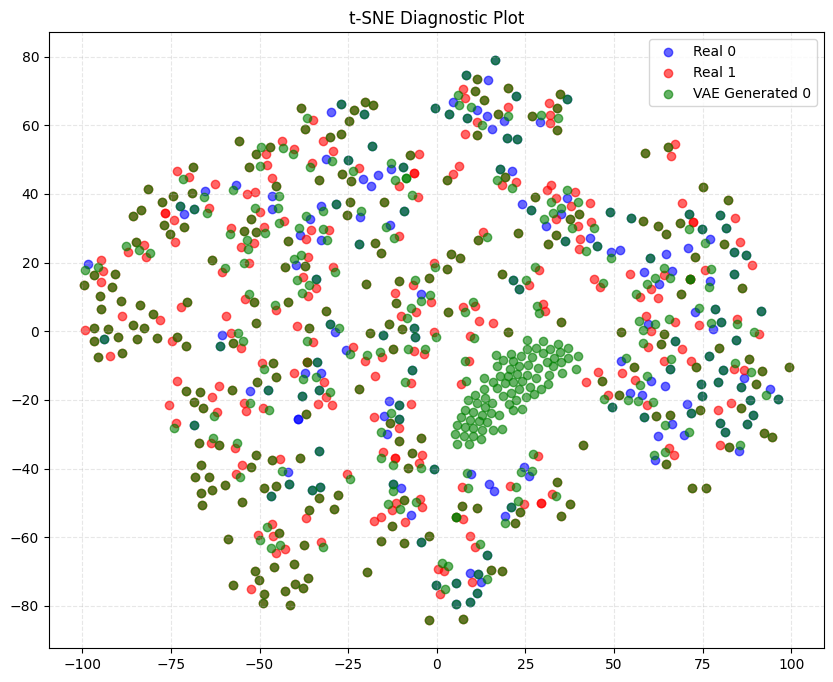

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

x_vae_0, _ = sampling_fn(80)
X = np.concatenate([x_0, x_1, x_vae_0], axis=0)

y = np.concatenate(
    [
        np.zeros(len(x_0)),
        np.ones(len(x_1)),
        np.ones(len(x_vae_0)) * 2,  
    ]
)


tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 8))
colors = ["blue", "red", "green"]
labels = ["Real 0", "Real 1", "VAE Generated 0"]

for i in range(3):
    idx = y == i
    plt.scatter(
        X_embedded[idx, 0],
        X_embedded[idx, 1],
        c=colors[i],
        label=labels[i],
        alpha=0.6,
    )
plt.grid(True, linestyle='--', alpha=0.3)

plt.legend()
plt.title("t-SNE Diagnostic Plot")
plt.savefig("tsne_diagnostic_plot.png", dpi=300, bbox_inches='tight')
plt.show()

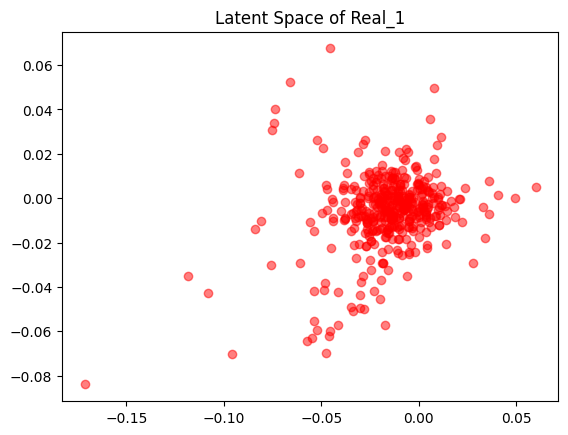

In [12]:
mu_1, _ = VAE_model.encode(x_1)
# 畫出 mu 的散點圖
plt.scatter(mu_1[:, 0].detach(), mu_1[:, 1].detach(), c='red', alpha=0.5)
plt.title("Latent Space of Real_1")
plt.show()

torch.Size([167, 6])


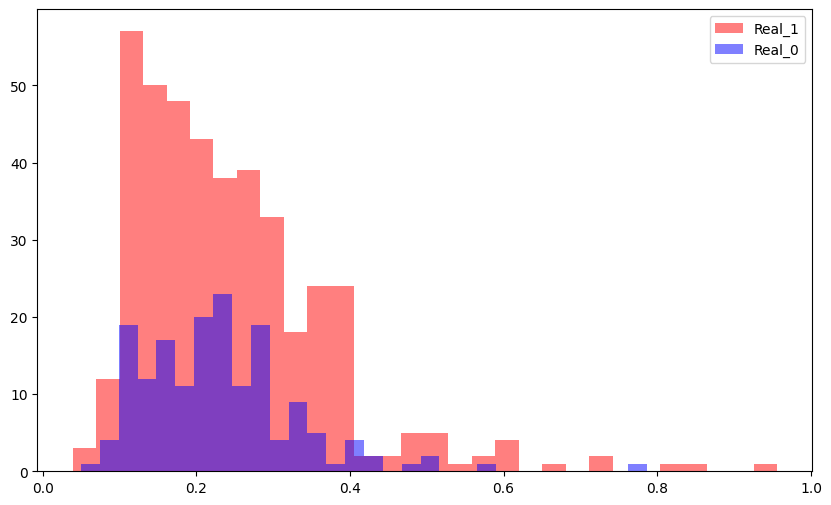

In [14]:
error_0 = get_recon_error(x_0)
error_1 = get_recon_error(x_1)

print(error_0.shape)


error_1_max = error_1.max(dim=1).values
error_0_max = error_0.max(dim=1).values

plt.figure(figsize=(10, 6))

plt.hist(error_1_max, bins=30, alpha=0.5, label='Real_1', color='red')
plt.hist(error_0_max, bins=30, alpha=0.5, label='Real_0', color='blue')
plt.legend()
plt.show()

In [105]:
class ResBlock(nn.Module):
    def __init__(self, features = 32):
        super().__init__()

        self.bn1 = nn.BatchNorm1d(features)
        self.fn1 = nn.Linear(features, features * 4)
        
        self.bn2 = nn.BatchNorm1d(features * 4)
        self.fn2 = nn.Linear(features * 4, features * 4)

        self.bn3 = nn.BatchNorm1d(features * 4)
        self.fn3 = nn.Linear(features * 4, features)
        
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        out = f.relu(self.bn1(x))
        out = self.dropout(self.fn1(out))
        
        out = f.relu(self.bn2(out))
        out = self.fn2(out)
        
        out = f.relu(self.bn3(out))
        out = self.fn3(out)
        
        return x + out

class BranchBlock(nn.Module):
    def __init__(self, features  = 32, depth = 3):
        super().__init__()
        self.res_layers = nn.ModuleList([
            ResBlock(features = features) for _ in range(depth)
        ])
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        for layer in self.res_layers:
            x = layer(x)
        x = self.dropout(x)
        
        return x

class Detection_model(nn.Module):
    def __init__(self, dim = 22, features = 128, num_resBlocks = 5, num_branchs = 5, gate = False):
        super().__init__()
        self.input = nn.Linear(dim, features)
        self.bn_in = nn.BatchNorm1d(features)
        
        self.fn1 = nn.Linear(features, features // 4)
        self.bn512_1 = nn.BatchNorm1d(features // 4)

        
        self.parallel_branchs = nn.ModuleList([
            BranchBlock(features = features // 4, depth = num_resBlocks) for _ in range(num_branchs)
        ])
        
                
        self.fnc2 = nn.Linear(features // 4, features)
        self.bn512_2 = nn.BatchNorm1d(features)
        self.output = nn.Linear(features, 1)

        self.gate = gate
        if self.gate:
            self.weights = ElementWeight(features = features // 4)
        else:
            self.register_parameter('weights', None)

    def forward(self, x):
        x = f.relu(self.bn_in(self.input(x)))
        x = f.relu(self.bn512_1(self.fn1(x)))

        parallel = sum(blocks(x) for blocks in self.parallel_branchs)
        
        if self.gate:
            parallel = self.weights(parallel)
        
        x = x + parallel 

        x = f.relu(self.bn512_2(self.fnc2(x)))
        x = self.output(x)

        return x

    def prediction(self, x):
        return self.forward(x)

class ElementWeight(nn.Module):
    def __init__(self, features=128):
        super().__init__()
        self.fn1 = nn.Linear(features, features)

    def forward(self, x):
        weights = torch.sigmoid(self.fn1(x))
        return x * weights


class NN(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.input = nn.Linear(dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fn = nn.Linear(512, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.output = nn.Linear(512, 1)

    def forward(self, x):
        x = f.relu(self.bn1(self.input(x)))
        x = f.relu(self.bn2(self.fn(x)))
        x = self.output(x)

        return x
        
print("ok")

ok


In [122]:
mode = 9


if mode == 0:
    training_data = x_train
    target = y_train
    detection_model = NN(dim = 11)
    
elif mode == 1:
    training_data, target = sampling_fn()
    detection_model = NN(dim = 11)
    
elif mode == 2:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = NN(dim = 22)
    
elif mode == 3:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = NN(dim = 22)
    
elif mode == 4:
    training_data = x_train
    target = y_train
    detection_model = Detection_model(dim = 11)
    
elif mode == 5:
    training_data, target = sampling_fn()
    detection_model = Detection_model(dim = 11)
    
elif mode == 6:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 22)
    
elif mode == 7:
    training_data, target = recon_error_fn(x_train, y_train)
    detection_model = Detection_model(dim = 22, gate = True)

elif mode == 8:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 22)
elif mode == 9:
    x_sample, y_sample = sampling_fn()
    training_data, target = data_aug_fn(x_sample, y_sample)

    detection_model = Detection_model(dim = 14, features = 128, num_resBlocks = 3, num_branchs = 4, gate = True)
    detection_model = detection_model.to(device)
else:
    x, y = sampling_fn()
    training_data, target = recon_error_fn(x, y)
    detection_model = Detection_model(dim = 22, gate = False)

pass
train_dataset = TensorDataset(training_data, target)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

#detection_model = Detection_model(num_resBlocks = 20, num_branchs = 5)
optim = AdamW(detection_model.parameters(), lr = 0.0001, weight_decay=0.05)

scheduler = ReduceLROnPlateau(optim, mode='min', factor=0.3, patience=10)

accuracy = Accuracy(task = "binary").to(device)
recall = Recall(task="binary").to(device)
f1 = BinaryF1Score().to(device)

epochs = 300

num_neg = (target == 0).sum().float()
num_pos = (target == 1).sum().float()
pos_weight = torch.tensor([num_neg / num_pos])

for epoch in range(epochs):
    detection_model.train()
    total_loss = 0
    
    epoch_preds = []
    epoch_targets = []

    for batch_x, batch_y in train_loader:
        optim.zero_grad()
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        y_pred_logits = detection_model(batch_x)
        
        y_pred_logits = y_pred_logits.squeeze() 
        batch_y = batch_y.squeeze()

        loss = f.binary_cross_entropy_with_logits(y_pred_logits, batch_y, pos_weight = pos_weight.to(device))
        loss.backward()
        optim.step()

        total_loss += loss.item() * len(batch_y)
        
        y_pred_prob = torch.sigmoid(y_pred_logits)
        epoch_preds.append(y_pred_prob.detach())
        epoch_targets.append(batch_y.detach())
        
    avg_loss = total_loss / len(training_data)

    torch.nn.utils.clip_grad_norm_(detection_model.parameters(), max_norm=1.0)
    scheduler.step(avg_loss)
    
    all_preds = torch.cat(epoch_preds)
    all_targets = torch.cat(epoch_targets)
    
    acc_score = accuracy(all_preds, all_targets)
    recall_score = recall(all_preds, all_targets)
    
    if (epoch+1) % 10 == 0:
        
        current_lr = optim.param_groups[0]['lr']
        print(f"epoch:[{epoch+1}/{epochs}]  loss: {avg_loss:.4f}  acc: {acc_score:.4f}  recall:{recall_score:.4f}  lr:{current_lr:.10f}") 


epoch:[10/300]  loss: 0.4504  acc: 0.6813  recall:0.6220  lr:0.0001000000
epoch:[20/300]  loss: 0.3945  acc: 0.7546  recall:0.7957  lr:0.0001000000
epoch:[30/300]  loss: 0.3670  acc: 0.7564  recall:0.7805  lr:0.0001000000
epoch:[40/300]  loss: 0.3468  acc: 0.7857  recall:0.7896  lr:0.0001000000
epoch:[50/300]  loss: 0.3152  acc: 0.8040  recall:0.7896  lr:0.0001000000
epoch:[60/300]  loss: 0.3029  acc: 0.8114  recall:0.8140  lr:0.0001000000
epoch:[70/300]  loss: 0.2789  acc: 0.8370  recall:0.8384  lr:0.0001000000
epoch:[80/300]  loss: 0.2698  acc: 0.8443  recall:0.8506  lr:0.0001000000
epoch:[90/300]  loss: 0.2424  acc: 0.8626  recall:0.8628  lr:0.0001000000
epoch:[100/300]  loss: 0.2267  acc: 0.8681  recall:0.8811  lr:0.0001000000
epoch:[110/300]  loss: 0.2239  acc: 0.8663  recall:0.8659  lr:0.0001000000
epoch:[120/300]  loss: 0.2160  acc: 0.8828  recall:0.8689  lr:0.0001000000
epoch:[130/300]  loss: 0.2096  acc: 0.8864  recall:0.8750  lr:0.0001000000
epoch:[140/300]  loss: 0.1982  acc

In [123]:
if mode not in {0,1,4,5,9} :
    VAE_model.eval()

    with torch.no_grad():

        mu, _ = VAE_model.encode(x_test)
        x_hat = VAE_model.decode(mu)
        
        recon_error = torch.abs(x_test - x_hat)
        x_augmented = torch.cat((x_test, recon_error), dim=1) 
    dataset = TensorDataset(x_augmented, y_test)

else:
    VAE_model.eval()
    with torch.no_grad():
        
        x_aug, y_aug = data_aug_fn(x_test, y_test)
        
        dataset = TensorDataset(x_aug, y_aug)
loader = DataLoader(dataset, batch_size=16, shuffle=False) 

all_preds = []
all_targets = []

detection_model.eval()

with torch.no_grad():
    for batch_x, batch_y in loader:

        batch_x, batch_y=batch_x.to(device), batch_y.to(device)
        y_logits = detection_model(batch_x)
        prob = torch.sigmoid(y_logits)
        
        y_pred = (prob >= 0.3).int()
        
        all_preds.append(y_pred.view(-1).cpu())
        all_targets.append(batch_y.view(-1).cpu())

final_preds = torch.cat(all_preds, dim=0)
final_targets = torch.cat(all_targets, dim=0).int()

accuracy.reset()
recall.reset()
f1.reset()
metric_acc = accuracy(final_preds, final_targets)
metric_recall = recall(final_preds, final_targets)
metric_f1 = f1(final_preds, final_targets)

print(f"--- 全測試集評估結果 ---")
print(f"Accuracy: {metric_acc.item():.4f}")
print(f"Recall:   {metric_recall.item():.4f}")
print(f"f1 score: {metric_f1.item():.4f}")

print("\n預測的前 50 筆結果:")
print(final_preds[:50].cpu().numpy()) 

--- 全測試集評估結果 ---
Accuracy: 0.7265
Recall:   0.8750
f1 score: 0.8280

預測的前 50 筆結果:
[1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1
 1 0 1 1 0 1 1 1 1 1 1 1 1]


In [23]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test.view(-1, 1), final_targets))

[[29  0]
 [ 0 88]]


In [24]:
print(y_test.view(-1, 1).shape)
print(y_pred.shape)

torch.Size([117, 1])
torch.Size([16, 1])
